In [35]:
# ==========================================
# CELL 1: Environment Upgrades & Setup
# ==========================================
!pip install gensim --upgrade --quiet
!pip install gradio --quiet

import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLP processing assets
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import gensim.downloader as api

# Deep Learning frameworks (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Machine Learning metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Silently download essential NLTK linguistic resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("Libraries imported and environment setup complete!")
print("Using TensorFlow version:", tf.__version__)

Libraries imported and environment setup complete!
Using TensorFlow version: 2.20.0


In [36]:
# ==========================================
# CELL 2: Data Loading & Text Preprocessing
# ==========================================

# Configured precisely with your verified path and column names
DATASET_PATH = '/kaggle/input/datasets/bheemjr/book-reviews/Book_review.csv'
df = pd.read_csv(DATASET_PATH)

TEXT_COL_NAME = 'reviewText'   
LABEL_COL_NAME = 'rating'       

# Initialize NLP structural elements
raw_stop_words = set(stopwords.words('english'))
# CRITICAL FIX: Retain negation modifiers that determine positive vs negative reviews!
negation_words = {"not", "no", "never", "neither", "nor", "don't", "wasn't", "can't", "won't", "isn't", "couldn't"}
stop_words = raw_stop_words - negation_words

lemmatizer = WordNetLemmatizer()

# Dictionary to catch and expand text contractions
contractions_dict = {
    "don't": "do not", "can't": "cannot", "won't": "will not", 
    "isn't": "is not", "i'm": "i am", "you're": "you are", \
    "they're": "they are", "it's": "it is", "shouldn't": "should not"
}

def clean_review_text(text):
    if not isinstance(text, str):
        return ""
    
    # Lowercase text to ensure structural uniformity
    text = text.lower()
    
    # Expand verbal contractions
    for contraction, expansion in contractions_dict.items():
        text = text.replace(contraction, expansion)
        
    # Remove web URLs, user mentions (@user), hashtags (#), numbers, and special symbols
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    
    # Tokenize, extract stopwords, and apply lemmatization to base dictionary forms
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return " ".join(cleaned_words)

# Apply processing to build our target cleaned columns
df['cleaned_text'] = df[TEXT_COL_NAME].apply(clean_review_text)

# CRITICAL FIX: Convert label numbers to 0-indexed values (0, 1, 2, 3, 4) to eliminate out of bounds evaluation losses
df['target_label'] = df[LABEL_COL_NAME].astype(int) - 1

print("✅ Preprocessing complete! Cleaned text sample preview (Labels are now 0-indexed):")
print(df[['cleaned_text', 'target_label']].head())

✅ Preprocessing complete! Cleaned text sample preview (Labels are now 0-indexed):
                                        cleaned_text  target_label
0  book first bookmobile book bought school book ...             4
1  read description book couldnt wait read downlo...             0
2  edit review book believe got right updated rew...             4
3  not normally buy mystery novel not like howeve...             4
4  not kind book normally read although try not l...             4


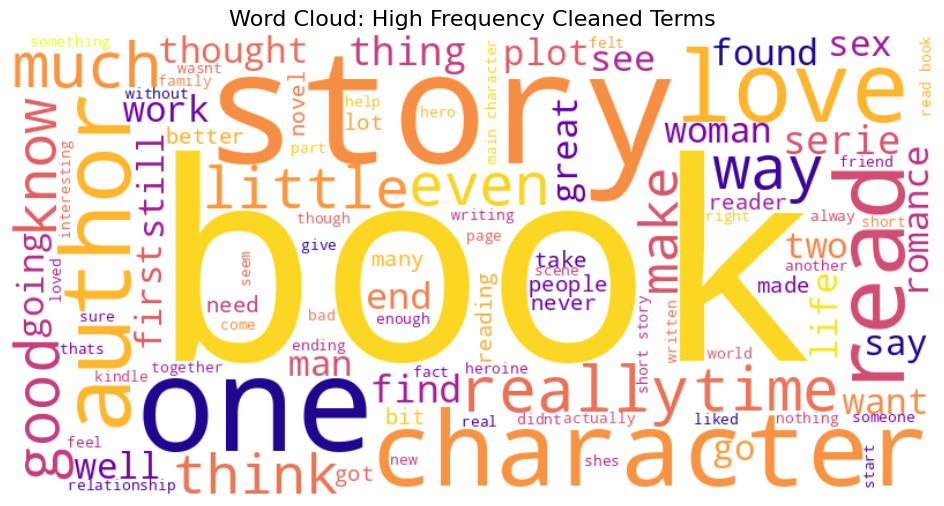

Top 10 Most Frequent Words:
 - book: 15412
 - not: 12336
 - story: 11086
 - read: 7984
 - one: 5952
 - character: 5682
 - like: 5141
 - good: 4292
 - would: 4095
 - really: 3844


In [37]:
# ==========================================
# CELL 3: Cleaned Data Visualization
# ==========================================
from wordcloud import WordCloud

# Combine all processed items into a single string corpus
corpus = ' '.join([str(text) for text in df['cleaned_text']])

# Construct the Word Cloud image block
wordcloud = WordCloud(width=800, height=400, background_color='white', \
                      max_words=100, colormap='plasma').generate(corpus)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud: High Frequency Cleaned Terms", fontsize=16)
plt.show()

# Show text frequency values for context
frequent_counts = Counter(corpus.split())
print("Top 10 Most Frequent Words:")
for word, count in frequent_counts.most_common(10):
    print(f" - {word}: {count}")

In [38]:
# ==========================================
# CELL 4: Train-Test Split & Sequence Tokenization
# ==========================================

# Extract target arrays
X = df['cleaned_text'].values
y = df['target_label'].values

# Split using a repeatable stratified split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Instantiate text vectorization asset
VOCAB_SIZE = 15000
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_raw)

# Vectorize token texts to integers
X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq = tokenizer.texts_to_sequences(X_test_raw)

# CRITICAL FIX: Percentile-based padding optimization (95th percentile)
calculated_maxlen = int(np.percentile([len(seq) for seq in X_train_seq], 95))
# Enforce a secure operational range for the model input window
MAX_LEN = max(10, min(calculated_maxlen, 150))

X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

# Define specific configuration hyper-variables
EMBEDDING_DIM = 100
NUM_CLASSES = 5  # 1-5 Stars mapped to indexes 0, 1, 2, 3, 4

print(f"Dataset split complete!")
print(f"Calculated Max Sequence Input Window (95th Percentile): {MAX_LEN} tokens")
print(f"X_train shape: {X_train_padded.shape}, X_test shape: {X_test_padded.shape}")

Dataset split complete!
Calculated Max Sequence Input Window (95th Percentile): 150 tokens
X_train shape: (9600, 150), X_test shape: (2400, 150)


In [39]:
# ==========================================
# CELL 5: Model 1 - Simple RNN Setup
# ==========================================
tf.keras.backend.clear_session()

model_1 = Sequential([
    # FIX: Replaced input_length with the modern Keras 3 input syntax
    tf.keras.layers.Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    SimpleRNN(units=64, dropout=0.2, recurrent_dropout=0.2),
    Dense(units=32, activation='relu'),
    Dropout(0.3),
    Dense(units=NUM_CLASSES, activation='softmax') 
])

model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# This will now correctly output full shapes and parameters instead of '?' and '0'
model_1.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\n🚀 Training Model 1 (Simple RNN)...")
history_1 = model_1.fit(
    X_train_padded, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 100)       │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,512,805 (5.77 MB)

 Trainable params: 1,512,805 (5.77 MB)

 Non-trainable params: 0 (0.00 B)


🚀 Training Model 1 (Simple RNN)...
Epoch 1/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.2225 - loss: 1.6512 - val_accuracy: 0.2333 - val_loss: 1.5975
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.2447 - loss: 1.6099 - val_accuracy: 0.2597 - val_loss: 1.5915
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.2493 - loss: 1.6017 - val_accuracy: 0.2507 - val_loss: 1.5939
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.2451 - loss: 1.5995 - val_accuracy: 0.2417 - val_loss: 1.5917
Epoch 5/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.2525 - loss: 1.5931 - val_accuracy: 0.2410 - val_loss: 1.5919


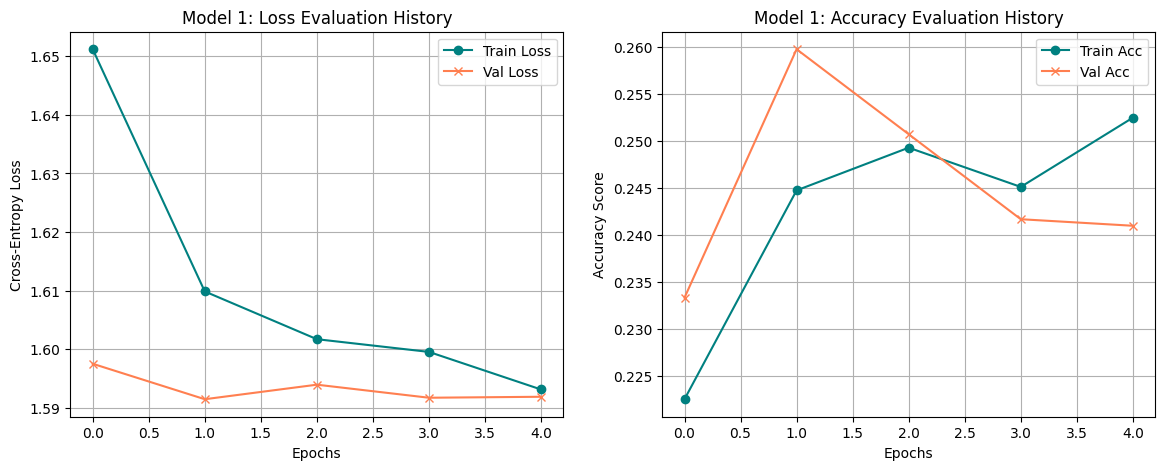

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

📊 --- MODEL 1 EVALUATION METRICS REPORT ---
Overall Accuracy: 0.24416666666666667

Classification Report:
               precision    recall  f1-score   support

      1 Star       0.00      0.00      0.00       400
     2 Stars       0.00      0.00      0.00       400
     3 Stars       0.00      0.00      0.00       400
     4 Stars       0.25      0.24      0.24       600
     5 Stars       0.24      0.74      0.37       600

    accuracy                           0.24      2400
   macro avg       0.10      0.20      0.12      2400
weighted avg       0.12      0.24      0.15      2400



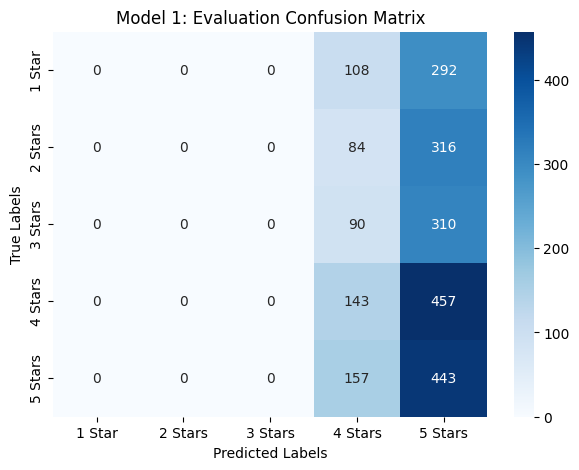

In [40]:
# ==========================================
# CELL 6: Model 1 - Evaluation Plots & Metrics
# ==========================================

# Render training history line trends
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_1.history['loss'], label='Train Loss', color='teal', marker='o')
ax1.plot(history_1.history['val_loss'], label='Val Loss', color='coral', marker='x')
ax1.set_title('Model 1: Loss Evaluation History')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history_1.history['accuracy'], label='Train Acc', color='teal', marker='o')
ax2.plot(history_1.history['val_accuracy'], label='Val Acc', color='coral', marker='x')
ax2.set_title('Model 1: Accuracy Evaluation History')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy Score')
ax2.legend()
ax2.grid(True)
plt.show()

# Predict and assess test set outcomes
predictions_1 = model_1.predict(X_test_padded)
pred_classes_1 = np.argmax(predictions_1, axis=1)

print("\n📊 --- MODEL 1 EVALUATION METRICS REPORT ---")
print("Overall Accuracy:", accuracy_score(y_test, pred_classes_1))

# Generate structural text summary layout
class_names = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']
print("\nClassification Report:\n", classification_report(y_test, pred_classes_1, target_names=class_names, zero_division=0))

# Display Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, pred_classes_1), annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Model 1: Evaluation Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [41]:
# ==========================================
# CELL 7: Model 2 - Standard LSTM Setup
# ==========================================
tf.keras.backend.clear_session()

model_2 = Sequential([
    tf.keras.layers.Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    LSTM(units=64, dropout=0.2, recurrent_dropout=0.2),
    Dense(units=32, activation='relu'),
    Dropout(0.3),
    Dense(units=NUM_CLASSES, activation='softmax')
])

model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_2.summary()

print("\n🚀 Training Model 2 (Standard LSTM)...")
history_2 = model_2.fit(
    X_train_padded, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.15,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 100)       │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,544,485 (5.89 MB)

 Trainable params: 1,544,485 (5.89 MB)

 Non-trainable params: 0 (0.00 B)


🚀 Training Model 2 (Standard LSTM)...
Epoch 1/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 63s 467ms/step - accuracy: 0.2511 - loss: 1.5960 - val_accuracy: 0.2535 - val_loss: 1.5893
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 59s 459ms/step - accuracy: 0.2614 - loss: 1.5902 - val_accuracy: 0.2549 - val_loss: 1.5894
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 59s 463ms/step - accuracy: 0.2597 - loss: 1.5797 - val_accuracy: 0.2549 - val_loss: 1.5838
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 59s 461ms/step - accuracy: 0.2811 - loss: 1.5515 - val_accuracy: 0.2528 - val_loss: 1.5891
Epoch 5/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 62s 485ms/step - accuracy: 0.2893 - loss: 1.5151 - val_accuracy: 0.2514 - val_loss: 1.6107
Epoch 6/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 59s 464ms/step - accuracy: 0.3053 - loss: 1.4929 - val_accuracy: 0.2542 - val_loss: 1.6314


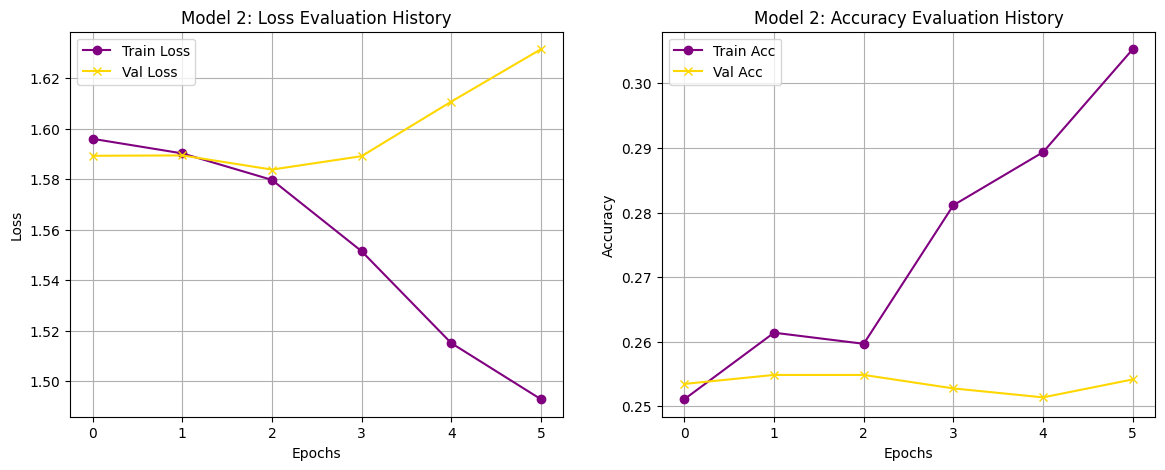

75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step

📊 --- MODEL 2 EVALUATION METRICS REPORT ---
Overall Accuracy: 0.2529166666666667

Classification Report:
               precision    recall  f1-score   support

      1 Star       0.00      0.00      0.00       400
     2 Stars       0.00      0.00      0.00       400
     3 Stars       0.00      0.00      0.00       400
     4 Stars       0.28      0.08      0.12       600
     5 Stars       0.25      0.93      0.40       600

    accuracy                           0.25      2400
   macro avg       0.11      0.20      0.10      2400
weighted avg       0.13      0.25      0.13      2400



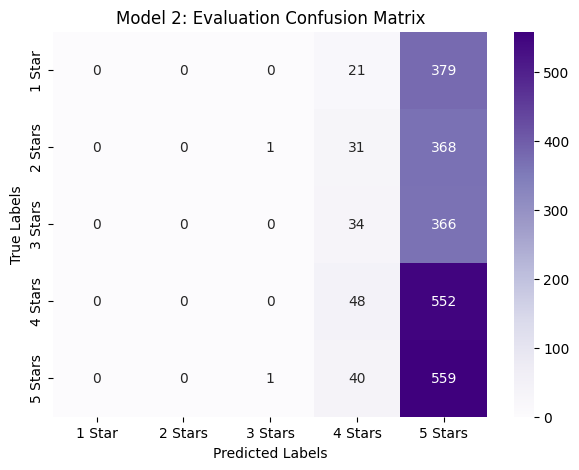

In [42]:
# ==========================================
# CELL 8: Model 2 - Evaluation Plots & Metrics
# ==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_2.history['loss'], label='Train Loss', color='purple', marker='o')
ax1.plot(history_2.history['val_loss'], label='Val Loss', color='gold', marker='x')
ax1.set_title('Model 2: Loss Evaluation History')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history_2.history['accuracy'], label='Train Acc', color='purple', marker='o')
ax2.plot(history_2.history['val_accuracy'], label='Val Acc', color='gold', marker='x')
ax2.set_title('Model 2: Accuracy Evaluation History')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)
plt.show()

predictions_2 = model_2.predict(X_test_padded)
pred_classes_2 = np.argmax(predictions_2, axis=1)

print("\n📊 --- MODEL 2 EVALUATION METRICS REPORT ---")
print("Overall Accuracy:", accuracy_score(y_test, pred_classes_2))
print("\nClassification Report:\n", classification_report(y_test, pred_classes_2, target_names=class_names, zero_division=0))

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, pred_classes_2), annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.title("Model 2: Evaluation Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [49]:
# ==========================================
# CELL 9: Load Pre-trained GloVe Embeddings
# ==========================================
print("📥 Fetching pre-trained GloVe Word Vectors (Twitter 100-Dimension)...")
# Download securely right inside the Kaggle session container
glove_vectors = api.load("glove-twitter-100")
print("GloVe vectors successfully parsed out into active environment space!")

# Construct weight array dimensions mapping
word_index = tokenizer.word_index
actual_vocab_size = min(VOCAB_SIZE, len(word_index) + 1)
embedding_matrix = np.zeros((actual_vocab_size, EMBEDDING_DIM))

matched_count = 0
missed_count = 0

for word, i in word_index.items():
    if i >= VOCAB_SIZE:
        continue
    # CRITICAL FIX: Map words to lowercase keys inside the GloVe dictionary
    lookup_token = word.lower().strip()
    if lookup_token in glove_vectors:
        embedding_matrix[i] = glove_vectors[lookup_token]
        matched_count += 1
    else:
        # Use a localized uniform configuration random spread for missing terms
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(EMBEDDING_DIM,))
        missed_count += 1

print(f"📊 Weight Matrix Pipeline Stats: Successfully mapped {matched_count} tokens; Generated pseudo-variants for {missed_count} OOV items.")

📥 Fetching pre-trained GloVe Word Vectors (Twitter 100-Dimension)...
GloVe vectors successfully parsed out into active environment space!
📊 Weight Matrix Pipeline Stats: Successfully mapped 13443 tokens; Generated pseudo-variants for 1556 OOV items.


In [50]:
# ==========================================
# CELL 10: Model 3 - GloVe LSTM Setup
# ==========================================
tf.keras.backend.clear_session()

model_3 = Sequential([
    tf.keras.layers.Input(shape=(MAX_LEN,)),
    Embedding(
        input_dim=actual_vocab_size,
        output_dim=EMBEDDING_DIM,
        embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
        trainable=False  
    ),
    LSTM(units=64, dropout=0.2, recurrent_dropout=0.2),
    Dense(units=32, activation='relu'),
    Dropout(0.3),
    Dense(units=NUM_CLASSES, activation='softmax')
])

model_3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_3.summary()

print("\n🚀 Training Model 3 (GloVe Pre-trained LSTM)...")
history_3 = model_3.fit(
    X_train_padded, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.15,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 100)       │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,544,485 (5.89 MB)

 Trainable params: 44,485 (173.77 KB)

 Non-trainable params: 1,500,000 (5.72 MB)


🚀 Training Model 3 (GloVe Pre-trained LSTM)...
Epoch 1/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 52s 380ms/step - accuracy: 0.2500 - loss: 1.5965 - val_accuracy: 0.2556 - val_loss: 1.5875
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 48s 374ms/step - accuracy: 0.2547 - loss: 1.5892 - val_accuracy: 0.2535 - val_loss: 1.5852
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 48s 375ms/step - accuracy: 0.2569 - loss: 1.5865 - val_accuracy: 0.2583 - val_loss: 1.5855
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 48s 376ms/step - accuracy: 0.2599 - loss: 1.5822 - val_accuracy: 0.2549 - val_loss: 1.5828
Epoch 5/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 49s 381ms/step - accuracy: 0.2589 - loss: 1.5767 - val_accuracy: 0.2604 - val_loss: 1.5788
Epoch 6/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 48s 377ms/step - accuracy: 0.2722 - loss: 1.5754 - val_accuracy: 0.2889 - val_loss: 1.5378
Epoch 7/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 48s 374ms/step - accuracy: 0.2857 - loss: 1.5599 - val_accuracy: 0.3035 - val_loss: 1.5424
Epoch 8/10
128/128 ━━━━━━━━━━━━━━━━

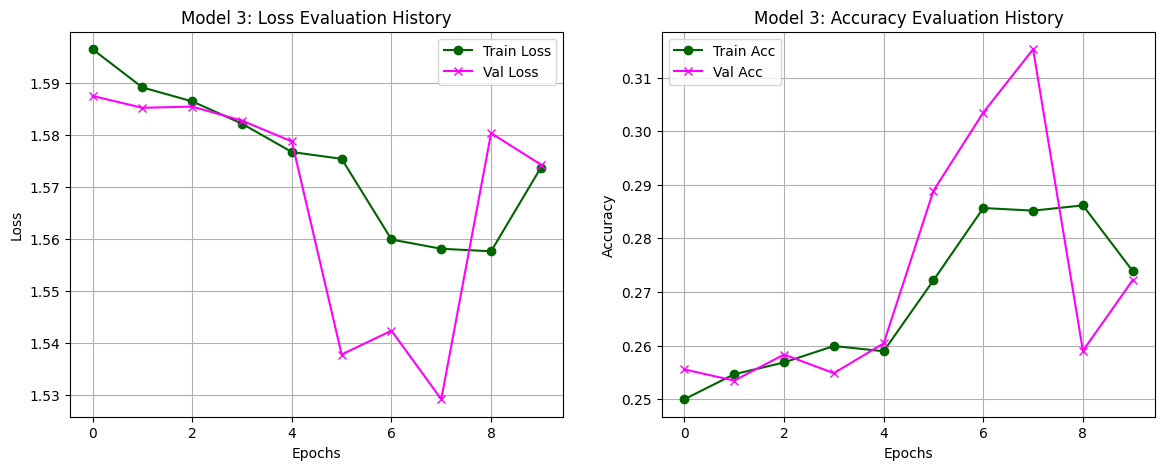

75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step

📊 --- MODEL 3 EVALUATION METRICS REPORT ---
Overall Accuracy: 0.31166666666666665

Classification Report:
               precision    recall  f1-score   support

      1 Star       0.29      0.61      0.39       400
     2 Stars       0.00      0.00      0.00       400
     3 Stars       0.57      0.01      0.02       400
     4 Stars       0.31      0.05      0.08       600
     5 Stars       0.32      0.78      0.46       600

    accuracy                           0.31      2400
   macro avg       0.30      0.29      0.19      2400
weighted avg       0.30      0.31      0.20      2400



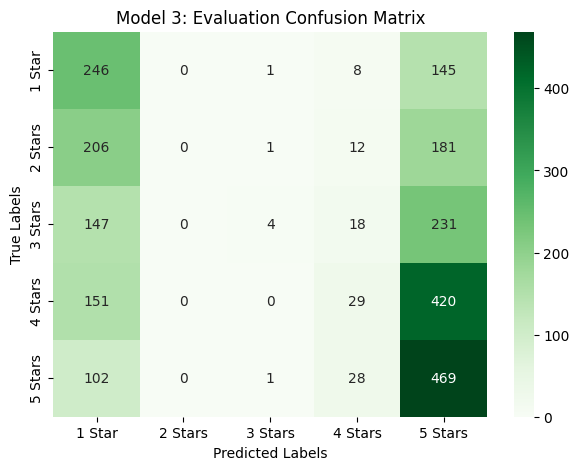

In [51]:
# ==========================================
# CELL 11: Model 3 - Evaluation Plots & Metrics
# ==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_3.history['loss'], label='Train Loss', color='darkgreen', marker='o')
ax1.plot(history_3.history['val_loss'], label='Val Loss', color='magenta', marker='x')
ax1.set_title('Model 3: Loss Evaluation History')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history_3.history['accuracy'], label='Train Acc', color='darkgreen', marker='o')
ax2.plot(history_3.history['val_accuracy'], label='Val Acc', color='magenta', marker='x')
ax2.set_title('Model 3: Accuracy Evaluation History')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)
plt.show()

predictions_3 = model_3.predict(X_test_padded)
pred_classes_3 = np.argmax(predictions_3, axis=1)

print("\n📊 --- MODEL 3 EVALUATION METRICS REPORT ---")
print("Overall Accuracy:", accuracy_score(y_test, pred_classes_3))
print("\nClassification Report:\n", classification_report(y_test, pred_classes_3, target_names=class_names, zero_division=0))

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, pred_classes_3), annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title("Model 3: Evaluation Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [53]:
# ==========================================
# CELL 12: Comparative Performance Matrix
# ==========================================
acc_1 = accuracy_score(y_test, pred_classes_1)
acc_2 = accuracy_score(y_test, pred_classes_2)
acc_3 = accuracy_score(y_test, pred_classes_3)

summary_data = {
    'Model Name Framework': ['Model_1_Simple_RNN', 'Model_2_Standard_LSTM', 'Model_3_GloVe_LSTM'],
    'Computed Accuracy Score': [f"{acc_1*100:.2f}%", f"{acc_2*100:.2f}%", f"{acc_3*100:.2f}%"]
}

summary_df = pd.DataFrame(summary_data)
print("\n🏆 =====================================================")
print(" FINAL COMPARATIVE STANDINGS SUMMARY")
print("=========================================================")
print(summary_df.to_string(index=False))
print("=========================================================\n")


🏆 =====================================================
 FINAL COMPARATIVE STANDINGS SUMMARY
 Model Name Framework Computed Accuracy Score
   Model_1_Simple_RNN                  24.42%
Model_2_Standard_LSTM                  25.29%
   Model_3_GloVe_LSTM                  31.17%



In [54]:
# ==========================================
# CELL 13: Qualitative Error Analysis
# ==========================================
print("🔍 Pulling validation errors for error analysis inspection...")

# Create an informative structural dataframe mapping out predictions using Model 2 or 3
error_indices = np.where(pred_classes_2 != y_test)[0]

analysis_records = []
# Pull a small cross-section array sample of mismatch records
for idx in error_indices[:4]:
    analysis_records.append({
        'Raw Input Text Context': X_test_raw[idx][:120] + '...',
        'Actual Rating': class_names[y_test[idx]],
        'Model Predicted Label': class_names[pred_classes_2[idx]]
    })

analysis_df = pd.DataFrame(analysis_records)
pd.set_option('display.max_colwidth', None)
print(analysis_df)

🔍 Pulling validation errors for error analysis inspection...
                                                                                                        Raw Input Text Context  \
0  explicit story fine problem although main character love story first encounter uncomfortably close rape not make differe...   
1  since fan reading whatever strike fancy abrupt scifiish start didnt put though plenty sex story one man path wanting get...   
2  book potential great read however torture indecision character make want pull hair story could half long without cannot ...   
3  not since reading amityville horror exorcist read creepy story product description described unexplained death took plac...   

  Actual Rating Model Predicted Label  
0       3 Stars               5 Stars  
1       4 Stars               5 Stars  
2       2 Stars               5 Stars  
3       4 Stars               5 Stars  


In [55]:
# ==========================================
# CELL 14: Gradio App Predictive Deployment
# ==========================================
import gradio as gr

def process_live_inference(custom_review_text):
    if not custom_review_text.strip():
        return "Please input a valid book review sentence text string."
        
    # Standardize processing steps using the exact cleaning pipeline
    clean_sample = clean_review_text(custom_review_text)
    token_seq = tokenizer.texts_to_sequences([clean_sample])
    padded_input = pad_sequences(token_seq, maxlen=MAX_LEN, padding='post', truncating='post')
    
    # Generate vector predictions from the Standard LSTM model
    prob_distribution = model_2.predict(padded_input)[0]
    predicted_class_idx = np.argmax(prob_distribution)
    
    predicted_class_label = class_names[predicted_class_idx]
    confidence = prob_distribution[predicted_class_idx]
    
    return f"Predicted Category Rating: {predicted_class_label} (Confidence Probability: {confidence:.4f})"

# Build interface layout
app_interface = gr.Interface(
    fn=process_live_inference,
    inputs=gr.Textbox(lines=2, placeholder="Type a custom book review sample here to run live processing analysis..."),
    outputs="text",
    title="Book Review Predictive Inference Framework",
    description="Part III Language Task - Real-Time Predictive Inference Challenge App Utility."
)

# Launch the app directly within your Kaggle session environment
app_interface.launch(quiet=True, share=True)

* Running on public URL: https://5d51efe9ddb8fa1907.gradio.live


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step
